# Data Driven Models: Logistic Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

## Learning Goals

* Describe properties of the logistic function $\sigma(x;W,b)$
* Compute values of the least sqares and cross entropy cost functions
* Compute optimal parameters for logistic regression
* Use logistic regression models to make predictions

### Pre-Lecture Activities

- [Course notes](https://ubcmath.github.io/MATH360/data-driven/logistic-regression/index.html): Logistic Regression including the subsections on the Logistic Function and Cost and Regularization

## Logistic Regression Models for Real Estate Classification

The data below was taken from [REALTOR.ca](https://www.realtor.ca) for properties in the Kitsilano neighborhood of Vancouver. The vector of listing prices is measured in millions of dollars. Logistic regression expects the target variable to have values 0 or 1. Define a new variable $y$ such that $y=0$ if the property has 1 bedroom and $y = 1$ if the property has 2 bedrooms. Let $x$ be the listing price and plot $x$ versus $y$.

In [9]:
prices = [0.499,0.549,0.565,0.579,0.619,0.625,0.638,0.695,0.729,0.749,0.749,0.789,0.799,0.825,0.848,0.850,0.885,0.895,0.925,0.998,1.055,1.08]
bedrooms = [1,1,1,1,1,1,1,1,2,1,2,1,2,2,1,2,2,2,2,2,2,2]

In [13]:
x = np.array(prices)
y = np.array([1 if x==2 else 0 for x in bedrooms])

sigma = lambda x,W,b: 1/(1 + np.exp(-(W*x + b)))

costLS = lambda W,b,x,y: 1/len(x)*np.sum((y - sigma(x,W,b))**2)
costCE = lambda W,b,x,y: -1/len(y)*np.sum(y*np.log(sigma(x,W,b)) + (1 - y)*np.log(1 - sigma(x,W,b)))

Text(0.5, 1.0, 'Prices vs Number of Bedrooms')

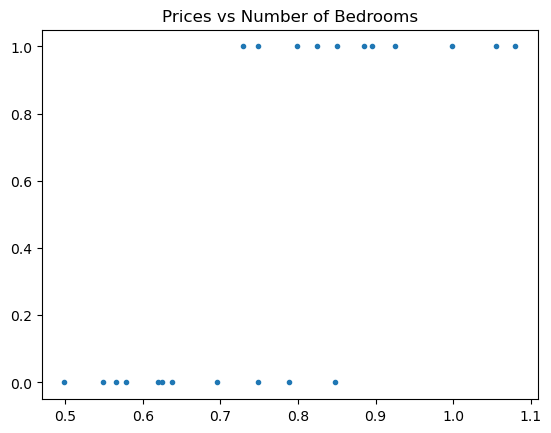

In [35]:
plt.plot(x,y, ".")
plt.title("Prices vs Number of Bedrooms")

Choose values $W$ and $b$ and plot the logistic function $\sigma(x;W,b)$. Use trial and error to find values $W$ and $b$ such that the logistic function fits the data.

Text(0.5, 1.0, 'Prices vs Number of Bedrooms')

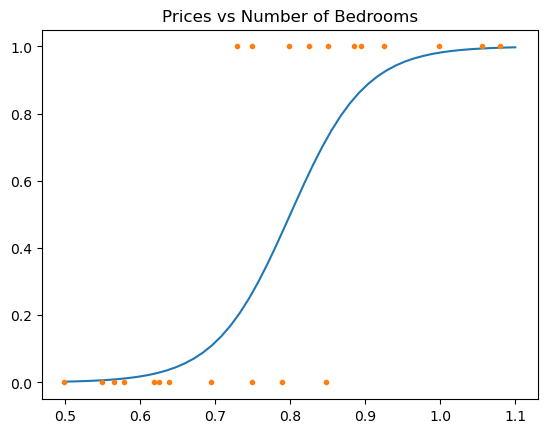

In [39]:
s1 = sigma(np.linspace(0.5, 1.1, 50), 20, -16)
plt.plot(np.linspace(0.5, 1.1, 50), s1)
plt.plot(x,y, ".")
plt.title("Prices vs Number of Bedrooms")

Compute the least squares cost $C_{LS}$ for the values $W$ and $b$ found in the previous step. Use trial and error to modify the values $W$ and $b$ to minimise $C_{LS}$. Plot the corresponding logistic function.

Use `scipy.optimize.minimize` to compute the optimal parameters $W$ and $b$ using the least squares cost function without regularization. Compare to the values $W$ and $b$ that you found in the previous steps.

In [41]:
# to use scipy.optimize.minimize we need the function to be of one variable so we now change it to be
F = lambda z: costLS(z[0], z[1], x, y)

In [42]:
minimize(F, [20, -16])

# things to look at
# x: output is the solution z[0]=16.37, z[1]=-12.455
# status: we want it to be zero, which means that it has found a minimum we do not want a negative value. 1-4 are terminating but not because we found a min
# fun: the cost function value that it found


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.10354111063705496
        x: [ 1.637e+01 -1.245e+01]
      nit: 19
      jac: [ 6.733e-07  1.376e-06]
 hess_inv: [[ 4.173e+03 -3.145e+03]
            [-3.145e+03  2.396e+03]]
     nfev: 66
     njev: 22

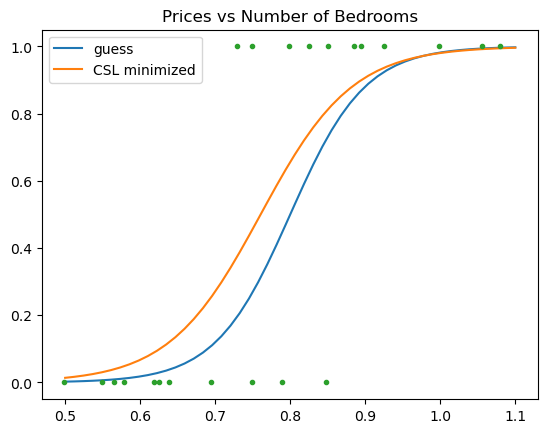

In [46]:
s1 = sigma(np.linspace(0.5, 1.1, 50), 20, -16)
s2 = sigma(np.linspace(0.5, 1.1, 50), 16.37, -12.45)
plt.plot(np.linspace(0.5, 1.1, 50), s1, label="guess")
plt.plot(np.linspace(0.5, 1.1, 50), s2, label="CSL minimized")
plt.plot(x,y, ".")
plt.title("Prices vs Number of Bedrooms")
plt.legend()
plt.show()

Use `scipy.optimize.minimize` to compute the optimal parameters $W$ and $b$ using the cross entropy cost function without regularization. Compare to the values $W$ and $b$ that you found in the previous steps.

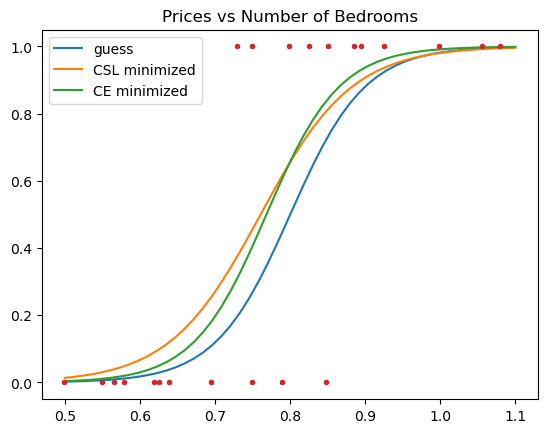

In [47]:
F = lambda z: costCE(z[0], z[1], x, y)
result = minimize(F, [20,-16])
w3, b3 = result.x

s1 = sigma(np.linspace(0.5, 1.1, 50), 20, -16)
s2 = sigma(np.linspace(0.5, 1.1, 50), 16.37, -12.45)
s3 = sigma(np.linspace(0.5, 1.1, 50), w3, b3)
plt.plot(np.linspace(0.5, 1.1, 50), s1, label="guess")
plt.plot(np.linspace(0.5, 1.1, 50), s2, label="CSL minimized")
plt.plot(np.linspace(0.5, 1.1, 50), s3, label="CE minimized")
plt.plot(x,y, ".")
plt.title("Prices vs Number of Bedrooms")
plt.legend()
plt.show()

Plot the logistic functions for the different values $W$ and $b$ found using $C_{LS}$ and $C_{CE}$. Is there much of a difference? Is it possible to describe how $C_{LS}$ and $C_{CE}$ measure error differently?

Use `scipy.optimize.minimize` to compute the optimal parameters $W$ and $b$ using the cross entropy cost function with L2 regularization for $\alpha=0.0,0.0001,0.001,0.01$. Plot the logistic function for each $\alpha$. What happens as $\alpha$ increases? Is L2 regularization improving the model?

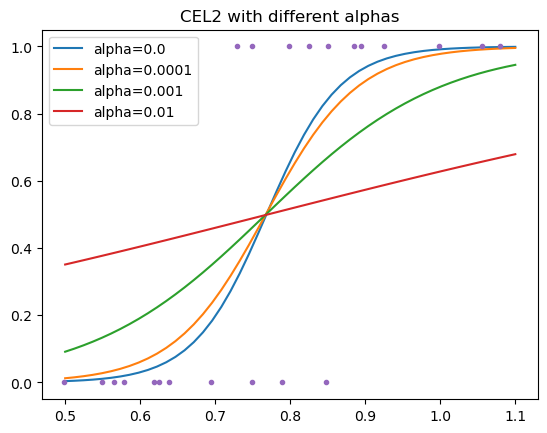

In [54]:
alpha = [0.0,0.0001,0.001,0.01]

costCEL2 = lambda W,b,x,y,alpha: -1/len(y)*np.sum(y*np.log(sigma(x,W,b)) + (1 - y)*np.log(1 - sigma(x,W,b))) + alpha*np.abs(W)**2

for a in alpha:
    F = lambda z: costCEL2(z[0], z[1], x, y, a)
    res = minimize(F, [20, -16])
    w, b = res.x
    plt.plot(np.linspace(0.5, 1.1, 50), sigma(np.linspace(0.5, 1.1, 50), w, b), label=f"alpha={a}")
    
plt.plot(x,y, ".")
plt.legend()
plt.title("CEL2 with different alphas")
plt.show()
    

The code below uses `sklearn.linear_model.LogisticRegression` to compute optimal parameters $W$ and $b$ for logistic regression. The result does not match any of our explicit calculations above. What is going on? Read the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to figure out how to use `sklearn` to reproduce the results above.

In [49]:
model = LogisticRegression().fit(x.reshape((len(x),1)),y)
W = model.coef_[0,0]
b = model.intercept_[0]
print('W =',W,', b =',b)

W = 1.154278212923914 , b = -0.8889606183595905


Construct the logistic regression model that you think best suits the data. Use the logistic regression model to find the listing price $P$ for which the model predicts a 2 bedroom property with 90% confidence.